In [6]:
import os
# Ensure notebook runs from repo root so relative paths to results/ work
os.chdir('..')


## Análisis Final con Optimización de Hiperparámetros
Clasificación (Antecedentes personales de cáncer, Sí/No)
Variable objetivo: presencia de antecedentes personales de cáncer.

Logistic Regression

Mejores parámetros: C=10, penalty=l2, solver=lbfgs.

Mejor F1 en validación ≈ 0.147.

Interpretación: el modelo logra un desempeño apenas superior al azar. Aunque la regularización más flexible permite mayor ajuste, la capacidad discriminativa sigue siendo baja.

Random Forest Classifier

Mejores parámetros: n_estimators=50, max_depth=None, min_samples_split=2, min_samples_leaf=1.

Mejor F1 en validación ≈ 0.081.

Interpretación: el modelo obtiene un F1 aún más bajo que Logistic Regression. A pesar de permitir árboles complejos, el modelo favorece la clase mayoritaria y no logra detectar adecuadamente los casos positivos.

Conclusión en clasificación  
 ambos modelos muestran F1 muy bajos, lo que confirma que el problema principal no está en los hiperparámetros, sino en el desbalance de clases y en la falta de variables predictivas fuertes.

Regresión (Tamaño máximo de la lesión en cm)
Variable objetivo: tamaño máximo de la lesión (valor numérico continuo).

Linear Regression

MAE ≈ 1.57, MSE ≈ 3.31, R² ≈ -0.024.

Interpretación: el modelo lineal no logra explicar la variabilidad del tamaño máximo de la lesión. El R² negativo indica desempeño inferior a una predicción basada en la media.

Random Forest Regressor

Mejores parámetros: n_estimators=200, max_depth=2, min_samples_split=2, min_samples_leaf=2.

Mejor R² en validación ≈ -0.023.

Interpretación: incluso con optimización, el modelo no mejora el ajuste. El R² negativo confirma que no se identifican patrones predictivos útiles en los datos.

Conclusión en regresión  
Ninguno de los modelos logra explicar la variabilidad del tamaño máximo de la lesión. El tuning confirma que el problema está en la información contenida en el dataset, más que en los hiperparámetros.



## Sección: Aprendizaje No Supervisado

A continuación se integra un flujo reproducible de aprendizaje no supervisado: PCA para reducción de dimensión, KMeans para clustering y visualización de clusters con cálculo de métricas (silhouette, Davies-Bouldin, inertia donde aplique).


Prepared matrix shape: (1000, 6)


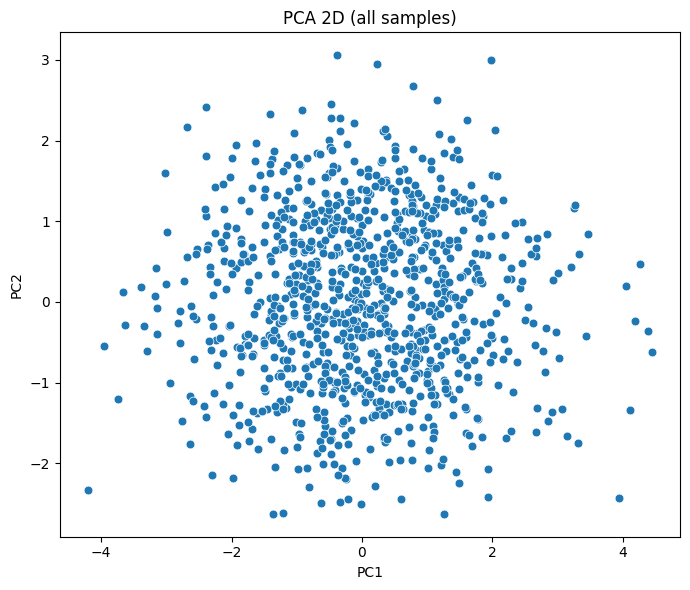

Selected k = 2 silhouette = 0.17689299020921595


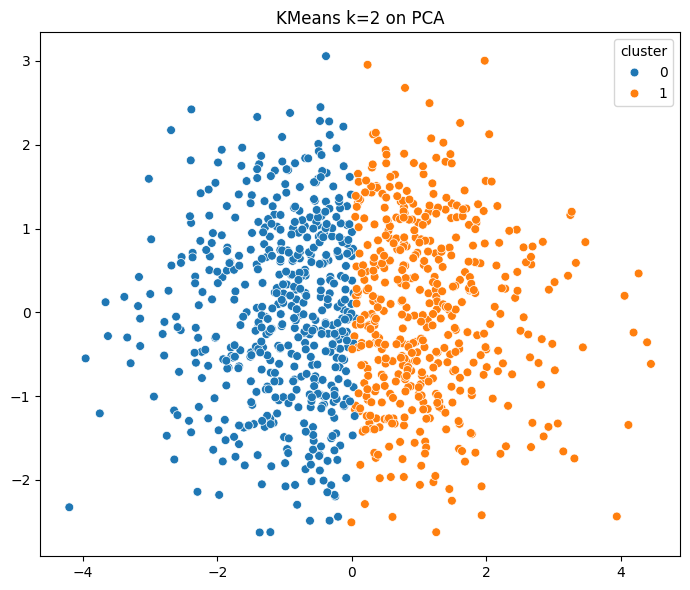

Saved metrics to C:\results\metrics\kmeans_integrated_metrics.csv


In [ ]:
# Código reproducible: PCA + KMeans + métricas y visualización

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from src.data_preprocessing import load_data

warnings.filterwarnings('ignore')


repo_root = Path.cwd().resolve()

while not (repo_root / 'src').exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent


plots_dir = results_dir / 'plots'
results_dir = repo_root / 'results'
metrics_dir = results_dir / 'metrics'


df = load_data("dataset_chile_cancer_piel.csv")

# Eliminar columnas no útiles para clustering
df = df.drop(
    columns=[
        'Antecedentes personales de cáncer',
        'Cáncer familiar 1er grado (tipo)'
    ],
    errors='ignore'
)

# Solo variables numéricas
X = df.select_dtypes(include=[np.number]).copy()
X = X.fillna(X.median())

# Escalado
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

print('Prepared matrix shape:', Xs.shape)


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(Xs)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], s=40)

plt.title('PCA 2D (all samples)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.savefig(plots_dir / 'pca_2d_integrated.png', dpi=150)
plt.show()


rows = []
best_k = None
best_sil = -1
best_labels = None

for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(Xs)

    sil = silhouette_score(Xs, labels)
    db = davies_bouldin_score(Xs, labels)
    inertia = float(km.inertia_)

    rows.append({
        'method': 'KMeans',
        'k': k,
        'silhouette': sil,
        'davies_bouldin': db,
        'inertia': inertia
    })

    if sil > best_sil:
        best_sil = sil
        best_k = k
        best_labels = labels

print('Selected k =', best_k, 'silhouette =', best_sil)


plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=best_labels,
    palette='tab10',
    s=40
)
plt.title(f'KMeans k={best_k} on PCA')
plt.legend(title='cluster')

plt.tight_layout()
plt.savefig(plots_dir / f'kmeans_k{best_k}_pca_integrated.png', dpi=150)
plt.show()
pd.DataFrame(rows).to_csv(
    metrics_dir / 'kmeans_integrated_metrics.csv',
    index=False
)
print('Saved metrics to', metrics_dir / 'kmeans_integrated_metrics.csv')

## Interpretación básica de resultados de clustering

- `silhouette_score` proporciona una medida de separación entre clusters; valores cercanos a 1 indican clusters bien separados.
- `Davies-Bouldin` más bajo indica mejor separación relativa.
- `inertia` (KMeans) indica compacidad interna; útil en elbow plot combinado con silhouette.

**Interpretación aplicada:** si KMeans con `k={}` presenta mejor `silhouette` que otros k, se recomienda usar ese k y revisar estabilidad mediante re-ejecuciones con diferentes seeds.
